<div style="background-color: darkred; padding: 10px; color: white;">

# Demo Segmentation Pipeline

</div>

### Imports

In [1]:
import numpy as np
import tifffile

from aind_exaspim_neuron_segmentation import inference
from aind_exaspim_neuron_segmentation.utils import img_util

<div style="background-color: darkblue; padding: 10px; color: white;">

## Section 1: Run Segmentation Pipeline
    
</div>

### Initializations

In [2]:
# Parameters
affinity_mode = True
batch_size = 16
device = "cuda"
overlap = (32, 32, 32)
patch_shape = (96, 96, 96)
trim = 8

# Load segmentation model
model_path = "/scratch/models/segmentation-data-challenge-09162025/UNet3d-20250903-583-0.8269.pth"
model = inference.load_model(model_path, affinity_mode=affinity_mode)

### Load Image

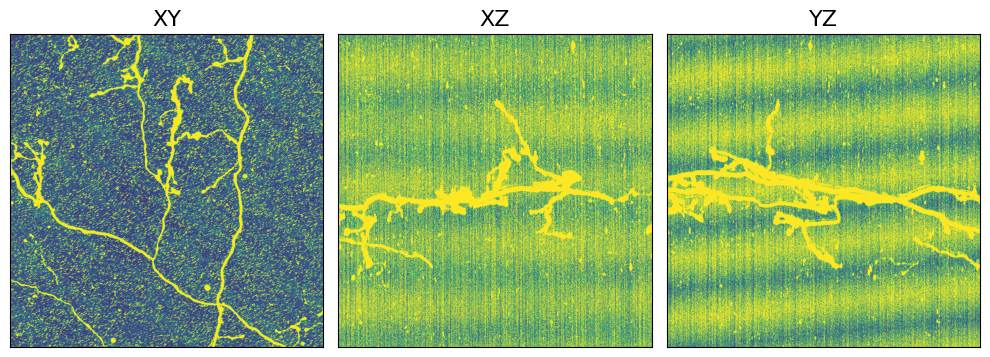

In [3]:
# Read image
block_id = "005"
img_path = f"s3://aind-benchmark-data/3d-image-compression/blocks/{block_id}/input.zarr/0"
img = img_util.read(img_path)[:]

# Visualize Image
img_util.plot_mips(img)

### Predict Affinities

Predict:   0%|          | 0/4096 [00:00<?, ?it/s]/opt/conda/lib/python3.10/site-packages/torch/nn/modules/conv.py:605: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at /opt/conda/conda-bld/pytorch_1695392020201/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv3d(
Predict: 100%|██████████| 4096/4096 [03:39<00:00, 18.65it/s]


Affinity Channel 0


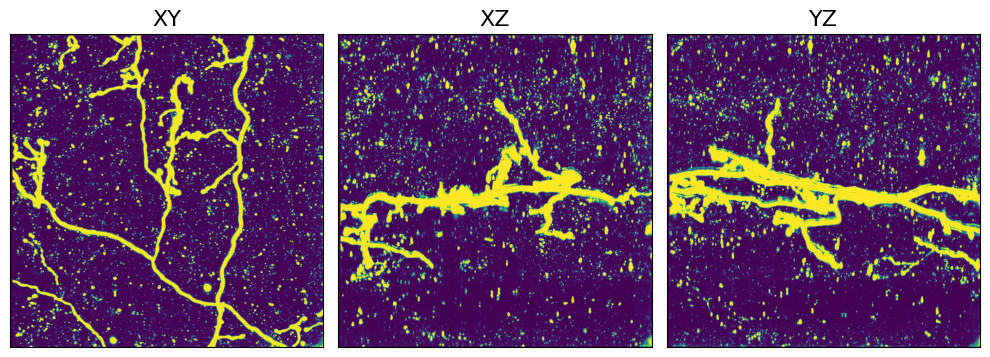

Affinity Channel 1


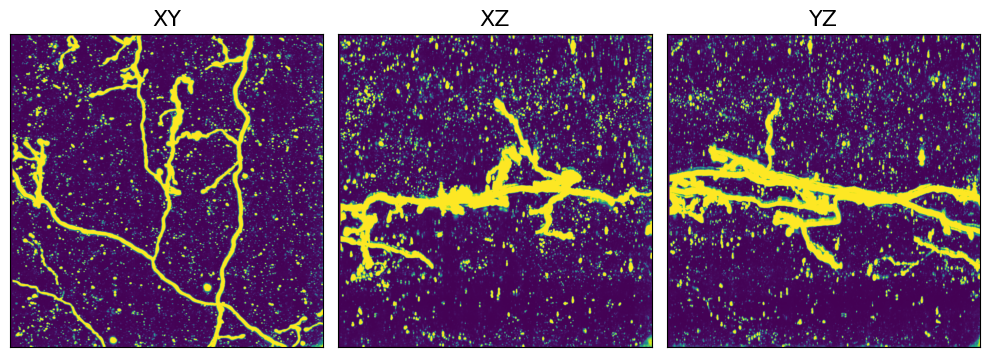

Affinity Channel 2


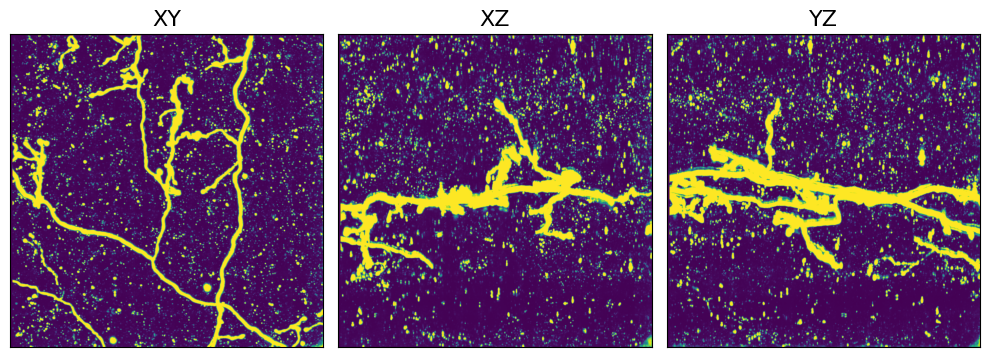

In [4]:
# Predict
affinites = inference.predict(
    img,
    model,
    affinity_mode=affinity_mode,
    batch_size=batch_size,
    overlap=overlap,
    patch_shape=patch_shape,
    trim=trim
)

# Visualize result
for i in range(3):
    print("Affinity Channel", i)
    img_util.plot_mips(affinites[i, ...])

### Generate Segmentation

Re-using already compiled waterz version


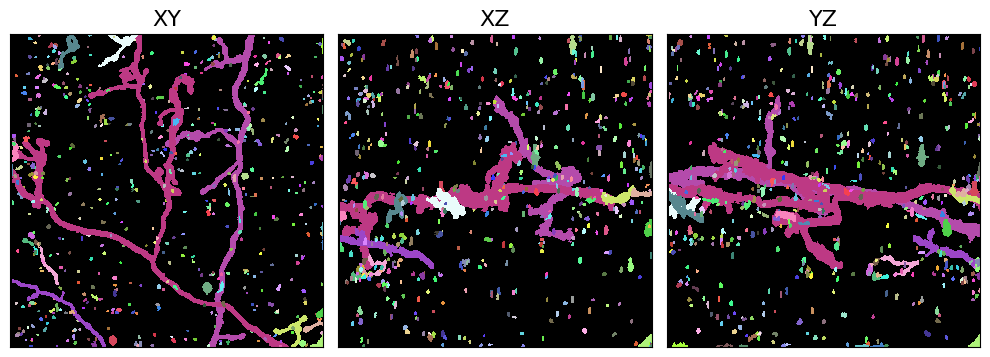

In [5]:
# Transform affinities to segmentation
segmentation = inference.affinities_to_segmentation(
    affinites,
    agglomeration_thresholds=[0.6, 0.8, 0.9],
    min_segment_size=500
)

# Visualize result
img_util.plot_segmentation_mips(segmentation)

### Save Results

In [6]:
# Save segmentation as SWC files
zipped_swcs_path = f"./swcs_{num}.zip"
inference.segmentation_to_zipped_swcs(segmentation, zipped_swcs_path)

# Save segmentation image
tifffile.imwrite(f"./segmentation_{num}.tiff", segmentation.astype(np.uint16))